In [101]:
# ============================================
# Imports Libs
# ============================================
import sys
from pathlib import Path

import warnings
import itertools

import numpy as np
import pandas as pd

import scipy
from scipy import stats

from sklearn import metrics

import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.ticker import FuncFormatter
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap

import seaborn as sns

from IPython.display import display

warnings.filterwarnings("ignore")

# ============================================
# Versions
# ============================================

print("python     =", sys.version.split()[0])
print("pandas     =", pd.__version__)
print("numpy      =", np.__version__)
print("scipy      =", scipy.__version__)
print("matplotlib =", mpl.__version__)
print("seaborn    =", sns.__version__)

python     = 3.11.15
pandas     = 2.3.3
numpy      = 2.4.6
scipy      = 1.17.1
matplotlib = 3.10.9
seaborn    = 0.13.2


In [102]:
# ============================================
# Paths
# ============================================

ROOT_DIR = Path("..")

RESULT_TABLE_DIR = ROOT_DIR / "results" / "table"
RESULT_FIGURE_DIR = ROOT_DIR / "results" / "figures"

RESULT_TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Tables :", RESULT_TABLE_DIR)
print("Figures:", RESULT_FIGURE_DIR)

Tables : ../results/table
Figures: ../results/figures


In [103]:
# ============================================
# Global plotting configuration
# ============================================

_PLOT_CFG = {
    "fig_w": 6.0,
    "fig_h": 5.0,
    "dpi": 300,
}


def set_plot_style(
    *,
    # Fonts
    base_fontsize=13,
    title_fontsize=16,
    label_fontsize=15,
    tick_fontsize=13,
    legend_fontsize=13,

    dpi=300,

    axes_linewidth=1.2,
    spines_top=True,
    spines_right=True,

    tick_size_major=6,
    tick_dir="out",

    grid=False,

    fig_w=6.0,
    fig_h=5.0,
):

    sns.set_style("ticks")

    mpl.rcParams.update({

        # =====================================
        # Fonts
        # =====================================
        "font.family": "DejaVu Sans",
        "font.size": base_fontsize,

        "axes.titlesize": title_fontsize,
        "axes.labelsize": label_fontsize,

        "xtick.labelsize": tick_fontsize,
        "ytick.labelsize": tick_fontsize,

        "legend.fontsize": legend_fontsize,

        # =====================================
        # Figure
        # =====================================
        "figure.dpi": dpi,
        "savefig.dpi": dpi,

        # =====================================
        # Axes
        # =====================================
        "axes.linewidth": axes_linewidth,
        "axes.spines.top": spines_top,
        "axes.spines.right": spines_right,
        "axes.grid": grid,
        "axes.axisbelow": True,

        # =====================================
        # Ticks
        # =====================================
        "xtick.major.size": tick_size_major,
        "ytick.major.size": tick_size_major,
        "xtick.direction": tick_dir,
        "ytick.direction": tick_dir,

        # =====================================
        # Legend
        # =====================================
        "legend.frameon": False,

        # =====================================
        # Save figure
        # =====================================
        "savefig.bbox": "tight",
        "savefig.transparent": False,
    })

    _PLOT_CFG.update({
        "fig_w": fig_w,
        "fig_h": fig_h,
        "dpi": dpi,
    })


def make_fig(
    w=None,
    h=None,
    dpi=None,
):
    W = float(w) if w is not None else _PLOT_CFG["fig_w"]
    H = float(h) if h is not None else _PLOT_CFG["fig_h"]
    D = dpi if dpi is not None else _PLOT_CFG["dpi"]

    fig, ax = plt.subplots(
        figsize=(W, H),
        dpi=D,
    )

    return fig, ax


set_plot_style()

In [104]:
# ============================================
# Benchmark plotting configuration
# ============================================

# Species
species_order = [
    "AT21",
    "NB21",
    "OS21",
]

species_label = {
    "AT21": "AT",
    "NB21": "NB",
    "OS21": "OS",
}

# Models
linear_models = [
    "PLS",
    "Ridge",
    "Lasso",
    "ElasticNet",
]

nonlinear_models = [
    "KernelRidge",
    "RandomForest",
    "XGBoost",
    "LightGBM",
]

model_order = linear_models + nonlinear_models

model_label = {
    "PLS": "PLS",
    "Ridge": "Ridge",
    "Lasso": "Lasso",
    "ElasticNet": "Elastic Net",
    "KernelRidge": "Kernel Ridge",
    "RandomForest": "Random Forest",
    "XGBoost": "XGBoost",
    "LightGBM": "LightGBM",
}

# Species colors
species_palette = {
    "AT21": "#6c5415",
    "NB21": "#7e3131",
    "OS21": "#13563f",
}

# Custom heatmap colormap
DrDb = LinearSegmentedColormap.from_list(
    "DrDb",
    [
        "#06080c",
        "#FFF9E7",
        "#910e0e",
    ],
)

In [105]:
# ============================================
# Formatting and saving helpers
# ============================================

def metric_formatter(decimals=2):
    return FuncFormatter(lambda x, _pos=None: f"{x:.{decimals}f}")


def compact_formatter(decimals=1):
    def _fmt(x, _pos=None):
        axx = abs(x)

        if axx >= 1e9:
            s = f"{x / 1e9:.{decimals}f}B"
        elif axx >= 1e6:
            s = f"{x / 1e6:.{decimals}f}M"
        elif axx >= 1e3:
            s = f"{x / 1e3:.{decimals}f}k"
        elif axx >= 10:
            s = f"{x:.0f}"
        else:
            s = f"{x:.2f}"

        return (
            s.replace(".0B", "B")
             .replace(".0M", "M")
             .replace(".0k", "k")
        )

    return FuncFormatter(_fmt)


def format_axis(
    ax,
    *,
    xlabel=None,
    ylabel=None,
    title=None,
    x_metric=False,
    y_metric=False,
    x_compact=False,
    y_compact=False,
    rotate_xticks=0,
):
    if xlabel is not None:
        ax.set_xlabel(xlabel)

    if ylabel is not None:
        ax.set_ylabel(ylabel)

    if title is not None:
        ax.set_title(title, pad=10)

    if x_metric:
        ax.xaxis.set_major_formatter(metric_formatter())

    if y_metric:
        ax.yaxis.set_major_formatter(metric_formatter())

    if x_compact:
        ax.xaxis.set_major_formatter(compact_formatter())

    if y_compact:
        ax.yaxis.set_major_formatter(compact_formatter())

    if rotate_xticks:
        ax.tick_params(axis="x", rotation=rotate_xticks)

    return ax


def save_fig(fig, filename):
    RESULT_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

    path = RESULT_FIGURE_DIR / filename

    fig.savefig(
        path,
        dpi=_PLOT_CFG["dpi"],
        bbox_inches="tight",
    )

    print(path)
    return path

In [106]:
# ============================================
# Load benchmark results
# ============================================

benchmark_file = RESULT_TABLE_DIR / "benchmark.tsv"

print(benchmark_file)
print("exists:", benchmark_file.exists())

benchmark_results_df = pd.read_csv(
    benchmark_file,
    sep="\t",
)

benchmark_results_df["species"] = pd.Categorical(
    benchmark_results_df["species"],
    categories=species_order,
    ordered=True,
)

benchmark_results_df["model"] = pd.Categorical(
    benchmark_results_df["model"],
    categories=model_order,
    ordered=True,
)

print(benchmark_results_df.shape)
display(benchmark_results_df.head())

../results/table/benchmark.tsv
exists: True
(48, 15)


,species,model,model_family,setting,CV_R2,CV_R2_sd,Train_R2,Test_R2,Train_Pearson_r,Test_Pearson_r,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,best_params
0,AT21,PLS,Linear,default,0.152271,0.034206,0.217031,0.178716,0.465866,0.424369,0.884855,0.911727,0.686262,0.716301,NaN
1,AT21,PLS,Linear,tuned,0.167010,0.033207,0.275754,0.190609,0.525123,0.443101,0.851026,0.905102,0.657794,0.704225,{'n_components': 26}
2,AT21,Ridge,Linear,default,0.170467,0.034620,0.288948,0.198109,0.537545,0.452137,0.843239,0.900898,0.652107,0.701203,NaN
3,AT21,Ridge,Linear,tuned,0.178043,0.031320,0.260004,0.198809,0.511346,0.447143,0.860230,0.900505,0.665015,0.704720,{'alpha': 319.923178995248}
4,AT21,Lasso,Linear,default,0.180112,0.031340,0.274173,0.199704,0.524158,0.449291,0.851955,0.900002,0.657953,0.703148,NaN


In [107]:
# ============================================
# Sanity check and column ordering
# ============================================

expected_cols = [
    "species",
    "model",
    "model_family",
    "setting",
    "CV_R2",
    "CV_R2_sd",
    "Train_R2",
    "Test_R2",
    "Train_Pearson_r",
    "Test_Pearson_r",
    "Train_RMSE",
    "Test_RMSE",
    "Train_MAE",
    "Test_MAE",
]

missing_cols = [
    c for c in expected_cols
    if c not in benchmark_results_df.columns
]

print("missing columns:", missing_cols)
print("n rows:", len(benchmark_results_df))
print("species:", benchmark_results_df["species"].unique())
print("models:", benchmark_results_df["model"].unique())
print("settings:", benchmark_results_df["setting"].unique())

benchmark_results_df = benchmark_results_df[expected_cols].copy()

benchmark_results_df["species"] = pd.Categorical(
    benchmark_results_df["species"],
    categories=species_order,
    ordered=True,
)

benchmark_results_df["model"] = pd.Categorical(
    benchmark_results_df["model"],
    categories=model_order,
    ordered=True,
)

benchmark_results_df = benchmark_results_df.sort_values(
    ["species", "model", "setting"]
).reset_index(drop=True)

display(benchmark_results_df)

missing columns: []
n rows: 48
species: ['AT21', 'NB21', 'OS21']
Categories (3, object): ['AT21' < 'NB21' < 'OS21']
models: ['PLS', 'Ridge', 'Lasso', 'ElasticNet', 'KernelRidge', 'RandomForest', 'XGBoost', 'LightGBM']
Categories (8, object): ['PLS' < 'Ridge' < 'Lasso' < 'ElasticNet' < 'KernelRidge' < 'RandomForest' < 'XGBoost' < 'LightGBM']
settings: ['default' 'tuned']


,species,model,model_family,setting,CV_R2,CV_R2_sd,Train_R2,Test_R2,Train_Pearson_r,Test_Pearson_r,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE
0,AT21,PLS,Linear,default,0.152271,0.034206,0.217031,0.178716,0.465866,0.424369,0.884855,0.911727,0.686262,0.716301
1,AT21,PLS,Linear,tuned,0.167010,0.033207,0.275754,0.190609,0.525123,0.443101,0.851026,0.905102,0.657794,0.704225
2,AT21,Ridge,Linear,default,0.170467,0.034620,0.288948,0.198109,0.537545,0.452137,0.843239,0.900898,0.652107,0.701203
3,AT21,Ridge,Linear,tuned,0.178043,0.031320,0.260004,0.198809,0.511346,0.447143,0.860230,0.900505,0.665015,0.704720
4,AT21,Lasso,Linear,default,0.180112,0.031340,0.274173,0.199704,0.524158,0.449291,0.851955,0.900002,0.657953,0.703148
5,AT21,Lasso,Linear,tuned,0.181505,0.030675,0.264091,0.200160,0.515073,0.448865,0.857851,0.899746,0.663129,0.704072
6,AT21,ElasticNet,Linear,default,0.177490,0.032535,0.281790,0.202450,0.531160,0.453159,0.847473,0.898457,0.654547,0.700453
7,AT21,ElasticNet,Linear,tuned,0.182333,0.030717,0.267860,0.199447,0.518455,0.448344,0.855652,0.900146,0.661121,0.703901
8,AT21,KernelRidge,Nonlinear,default,0.243076,0.037023,0.511295,0.282991,0.733514,0.533201,0.699074,0.851884,0.537384,0.652194
9,AT21,KernelRidge,Nonlinear,tuned,0.219974,0.041638,0.463943,0.264865,0.689375,0.517704,0.732159,0.862584,0.563441,0.662385


In [108]:
# ============================================
# Main metric table: Test R2
# ============================================

test_r2_table = (
    benchmark_results_df
    .pivot_table(
        index=[
            "species",
            "model_family",
            "model",
        ],
        columns="setting",
        values="Test_R2",
        observed=False,
    )
    .reset_index()
)

test_r2_table["delta_tuned_minus_default"] = (
    test_r2_table["tuned"]
    - test_r2_table["default"]
)

display(test_r2_table)

setting,species,model_family,model,default,tuned,delta_tuned_minus_default
0,AT21,Linear,PLS,0.178716,0.190609,0.011893
1,AT21,Linear,Ridge,0.198109,0.198809,0.000700
2,AT21,Linear,Lasso,0.199704,0.200160,0.000456
3,AT21,Linear,ElasticNet,0.202450,0.199447,-0.003003
4,AT21,Nonlinear,KernelRidge,0.282991,0.264865,-0.018126
5,AT21,Nonlinear,RandomForest,0.273023,0.297555,0.024532
6,AT21,Nonlinear,XGBoost,0.277110,0.280060,0.002950
7,AT21,Nonlinear,LightGBM,0.278224,0.294829,0.016605
8,NB21,Linear,PLS,0.184457,0.227468,0.043011
9,NB21,Linear,Ridge,0.235310,0.212692,-0.022618


In [109]:
# ============================================
# Ranking by Test R2
# ============================================

benchmark_rank_df = (
    benchmark_results_df
    .sort_values(
        ["species", "Test_R2"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

display(
    benchmark_rank_df[
        [
            "species",
            "model_family",
            "model",
            "setting",
            "Test_R2",
            "Test_Pearson_r",
            "Test_RMSE",
            "Test_MAE",
        ]
    ]
)

,species,model_family,model,setting,Test_R2,Test_Pearson_r,Test_RMSE,Test_MAE
0,AT21,Nonlinear,RandomForest,tuned,0.297555,0.547742,0.843188,0.641270
1,AT21,Nonlinear,LightGBM,tuned,0.294829,0.545113,0.844822,0.644520
2,AT21,Nonlinear,KernelRidge,default,0.282991,0.533201,0.851884,0.652194
3,AT21,Nonlinear,XGBoost,tuned,0.280060,0.530780,0.853623,0.652880
4,AT21,Nonlinear,LightGBM,default,0.278224,0.537620,0.854711,0.644343
5,AT21,Nonlinear,XGBoost,default,0.277110,0.535545,0.855371,0.644559
6,AT21,Nonlinear,RandomForest,default,0.273023,0.541205,0.857785,0.642146
7,AT21,Nonlinear,KernelRidge,tuned,0.264865,0.517704,0.862584,0.662385
8,AT21,Linear,ElasticNet,default,0.202450,0.453159,0.898457,0.700453
9,AT21,Linear,Lasso,tuned,0.200160,0.448865,0.899746,0.704072


In [110]:
# ============================================
# Benchmark summary statistics
# ============================================

summary_df = (
    benchmark_results_df
    .groupby(
        [
            "species",
            "model_family",
            "setting",
        ],
        observed=False,
    )
    .agg(
        mean_Test_R2=("Test_R2", "mean"),
        max_Test_R2=("Test_R2", "max"),
        min_Test_R2=("Test_R2", "min"),

        mean_Pearson=("Test_Pearson_r", "mean"),
        max_Pearson=("Test_Pearson_r", "max"),

        mean_RMSE=("Test_RMSE", "mean"),
        mean_MAE=("Test_MAE", "mean"),
    )
    .reset_index()
)

display(summary_df)

,species,model_family,setting,mean_Test_R2,max_Test_R2,min_Test_R2,mean_Pearson,max_Pearson,mean_RMSE,mean_MAE
0,AT21,Linear,default,0.194745,0.202450,0.178716,0.444739,0.453159,0.902771,0.705276
1,AT21,Linear,tuned,0.197256,0.200160,0.190609,0.446863,0.448865,0.901375,0.704230
2,AT21,Nonlinear,default,0.277837,0.282991,0.273023,0.536893,0.541205,0.854938,0.645810
3,AT21,Nonlinear,tuned,0.284327,0.297555,0.264865,0.535335,0.547742,0.851054,0.650264
4,NB21,Linear,default,0.220338,0.235310,0.184457,0.479718,0.498272,0.899371,0.691458
5,NB21,Linear,tuned,0.219421,0.227468,0.212692,0.475394,0.489237,0.899974,0.691888
6,NB21,Nonlinear,default,0.273091,0.282354,0.268047,0.536371,0.541141,0.868482,0.653813
7,NB21,Nonlinear,tuned,0.274717,0.295569,0.253766,0.526248,0.544706,0.867470,0.660176
8,OS21,Linear,default,0.229791,0.250114,0.177783,0.484507,0.508438,0.858783,0.665449
9,OS21,Linear,tuned,0.244892,0.246603,0.243125,0.498320,0.499832,0.850481,0.663041


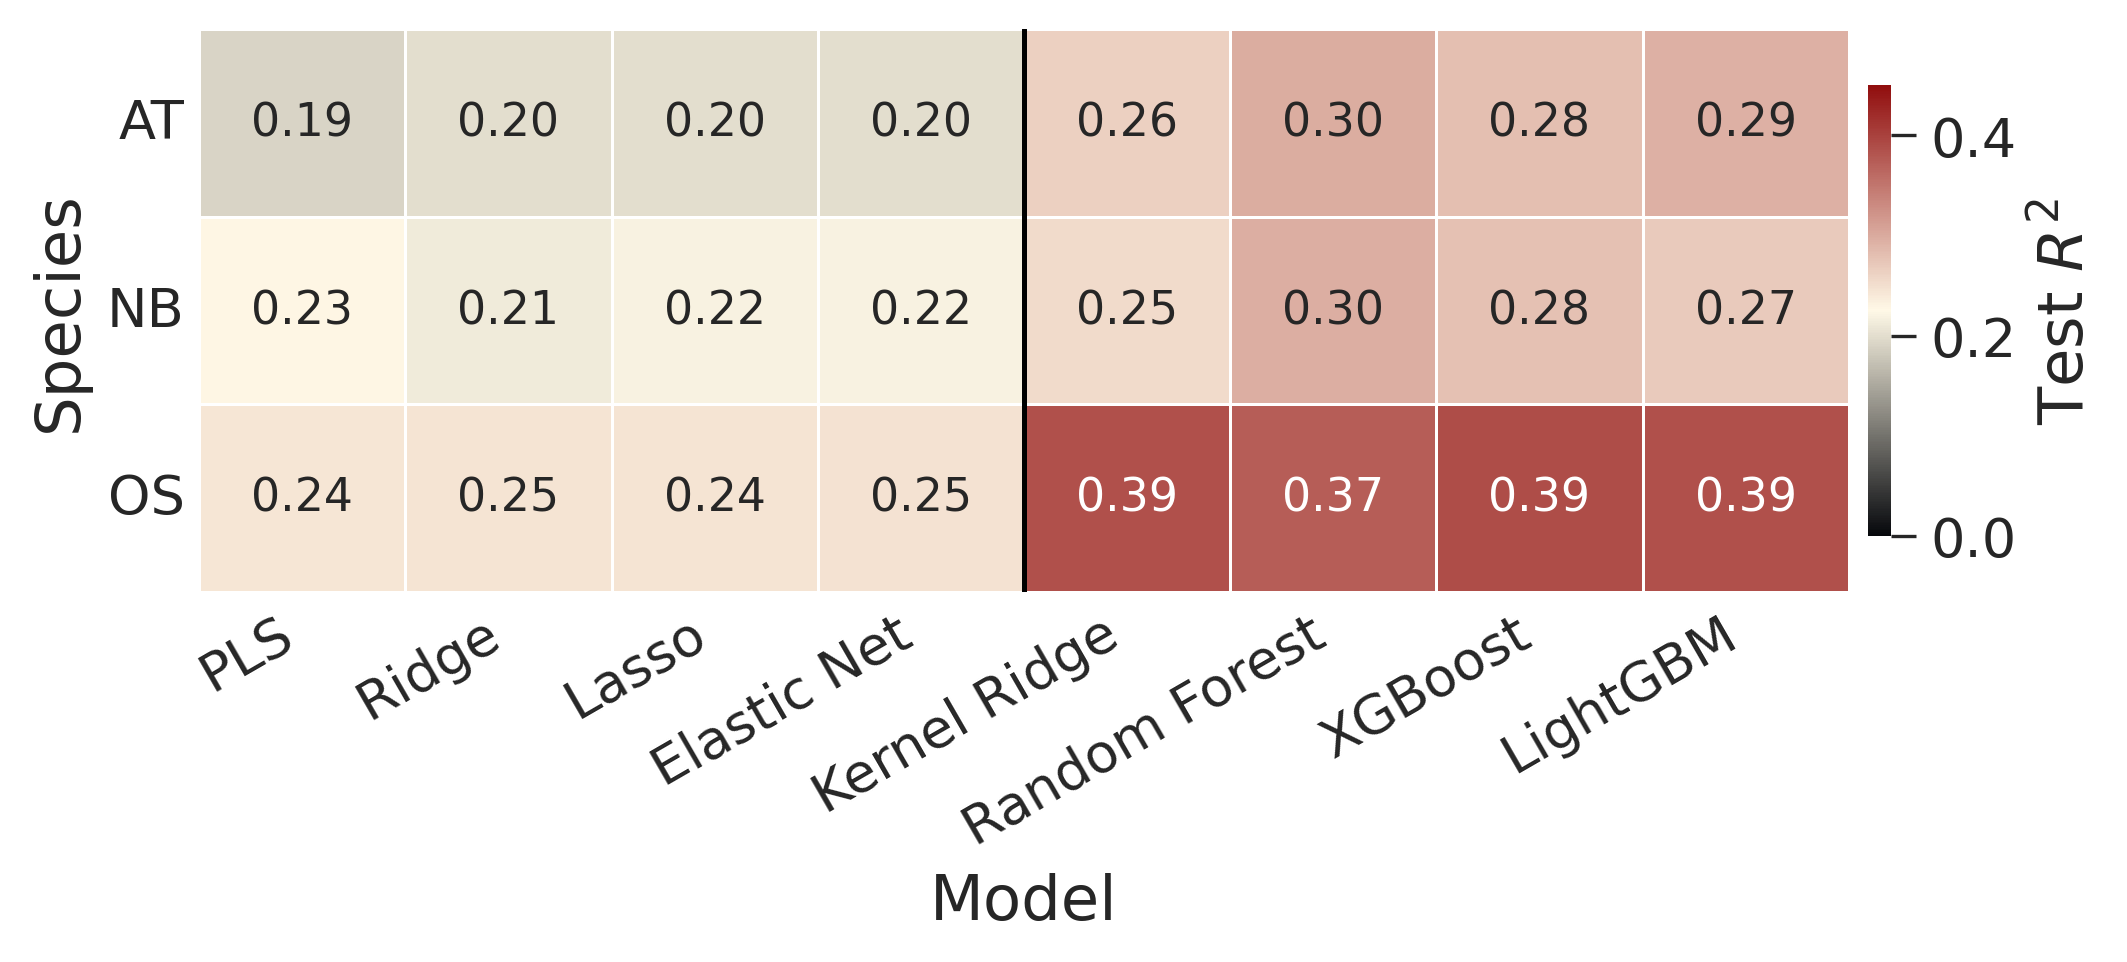

In [111]:
# ============================================
# Figure: Tuned Test R2 heatmap
# ============================================

heatmap_df = (
    benchmark_results_df
    .query("setting == 'tuned'")
    .pivot(
        index="species",
        columns="model",
        values="Test_R2",
    )
    .loc[species_order, model_order]
)

heatmap_df.index = [
    species_label[s]
    for s in heatmap_df.index
]

heatmap_df.columns = [
    model_label[m]
    for m in heatmap_df.columns
]

fig, ax = make_fig(
    w=7.5,
    h=3.4,
)

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    cmap=DrDb,
    vmin=0,
    vmax=0.45,
    linewidths=0.6,
    linecolor="white",
    annot_kws={
        "fontsize": 11,
    },
    cbar_kws={
        "label": r"Test $R^2$",
        "shrink": 0.80,
        "pad": 0.01,
    },
    ax=ax,
)

# separator between Linear and Nonlinear models
ax.axvline(
    len(linear_models),
    color="black",
    lw=1.2,
)

format_axis(
    ax,
    xlabel="Model",
    ylabel="Species",
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=30,
    ha="right",
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
)

ax.tick_params(
    axis="both",
    length=0,
)

plt.tight_layout()
plt.show()

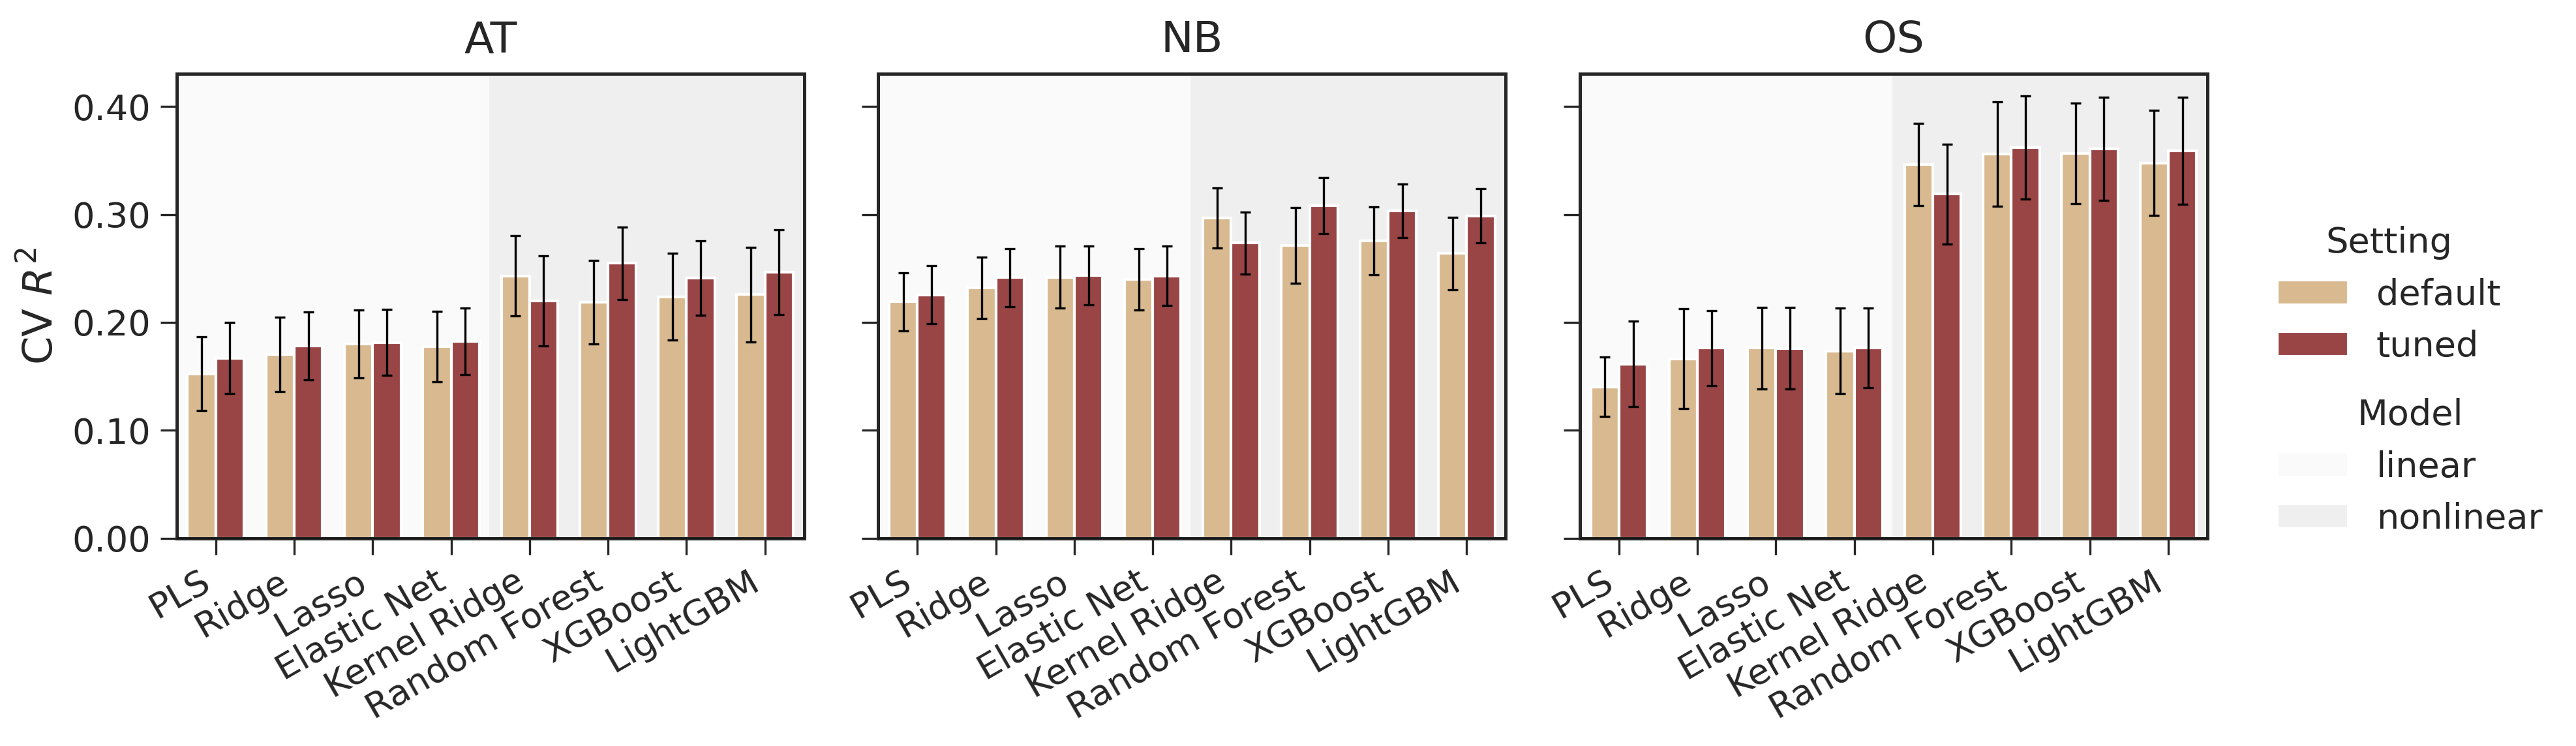

In [131]:
# ============================================
# Figure: Default vs Tuned CV R2 ± SD
# ============================================

setting_order = ["default", "tuned"]

setting_palette = {
    "default": "#D8B990",
    "tuned": "#994545",
}

model_type_palette = {
    "linear": "#FAFAFA",
    "nonlinear": "#EFEFEF",
}

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(13, 4),
    sharey=True,
)

bar_width = 0.36
x = np.arange(len(model_order))

linear_start = -0.5
linear_end = len(linear_models) - 0.5
nonlinear_start = linear_end
nonlinear_end = len(model_order) - 0.5

for ax, species in zip(axes, species_order):

    temp_df = (
        benchmark_results_df
        .query("species == @species")
        .copy()
    )

    ax.set_xlim(-0.5, len(model_order) - 0.5)

    # background: linear / nonlinear
    ax.axvspan(
        linear_start,
        linear_end,
        color=model_type_palette["linear"],
        zorder=0,
    )

    ax.axvspan(
        nonlinear_start,
        nonlinear_end,
        color=model_type_palette["nonlinear"],
        zorder=0,
    )

    for setting in setting_order:

        setting_df = (
            temp_df
            .query("setting == @setting")
            .set_index("model")
            .loc[model_order]
        )

        offset = -bar_width / 2 if setting == "default" else bar_width / 2

        ax.bar(
            x + offset,
            setting_df["CV_R2"],
            width=bar_width,
            color=setting_palette[setting],
            label=setting,
            yerr=setting_df["CV_R2_sd"],
            zorder=2,
            error_kw={
                "elinewidth": 0.8,
                "ecolor": "black",
                "capsize": 2,
                "capthick": 0.8,
            },
        )

    ax.axhline(
        0,
        color="black",
        lw=0.8,
        zorder=3,
    )

    ax.set_title(
        species_label[species],
        pad=8,
    )

    ax.set_xticks(x)

    ax.set_xticklabels(
        [model_label[m] for m in model_order],
        rotation=30,
        ha="right",
    )

    format_axis(
        ax,
        xlabel=None,
        ylabel=r"CV $R^2$" if species == species_order[0] else None,
        y_metric=True,
    )

    if species != species_order[0]:
        ax.set_ylabel("")


# ============================================
# Legends outside plot
# ============================================

from matplotlib.patches import Patch

setting_handles = [
    Patch(facecolor=setting_palette["default"], label="default"),
    Patch(facecolor=setting_palette["tuned"], label="tuned"),
]

model_handles = [
    Patch(facecolor=model_type_palette["linear"], label="linear"),
    Patch(facecolor=model_type_palette["nonlinear"], label="nonlinear"),
]

fig.legend(
    handles=setting_handles,
    title="Setting",
    loc="center left",
    bbox_to_anchor=(0.89, 0.60),
    frameon=False,
)

fig.legend(
    handles=model_handles,
    title="Model",
    loc="center left",
    bbox_to_anchor=(0.89, 0.38),
    frameon=False,
)

plt.tight_layout(rect=(0, 0, 0.89, 1))
plt.show()